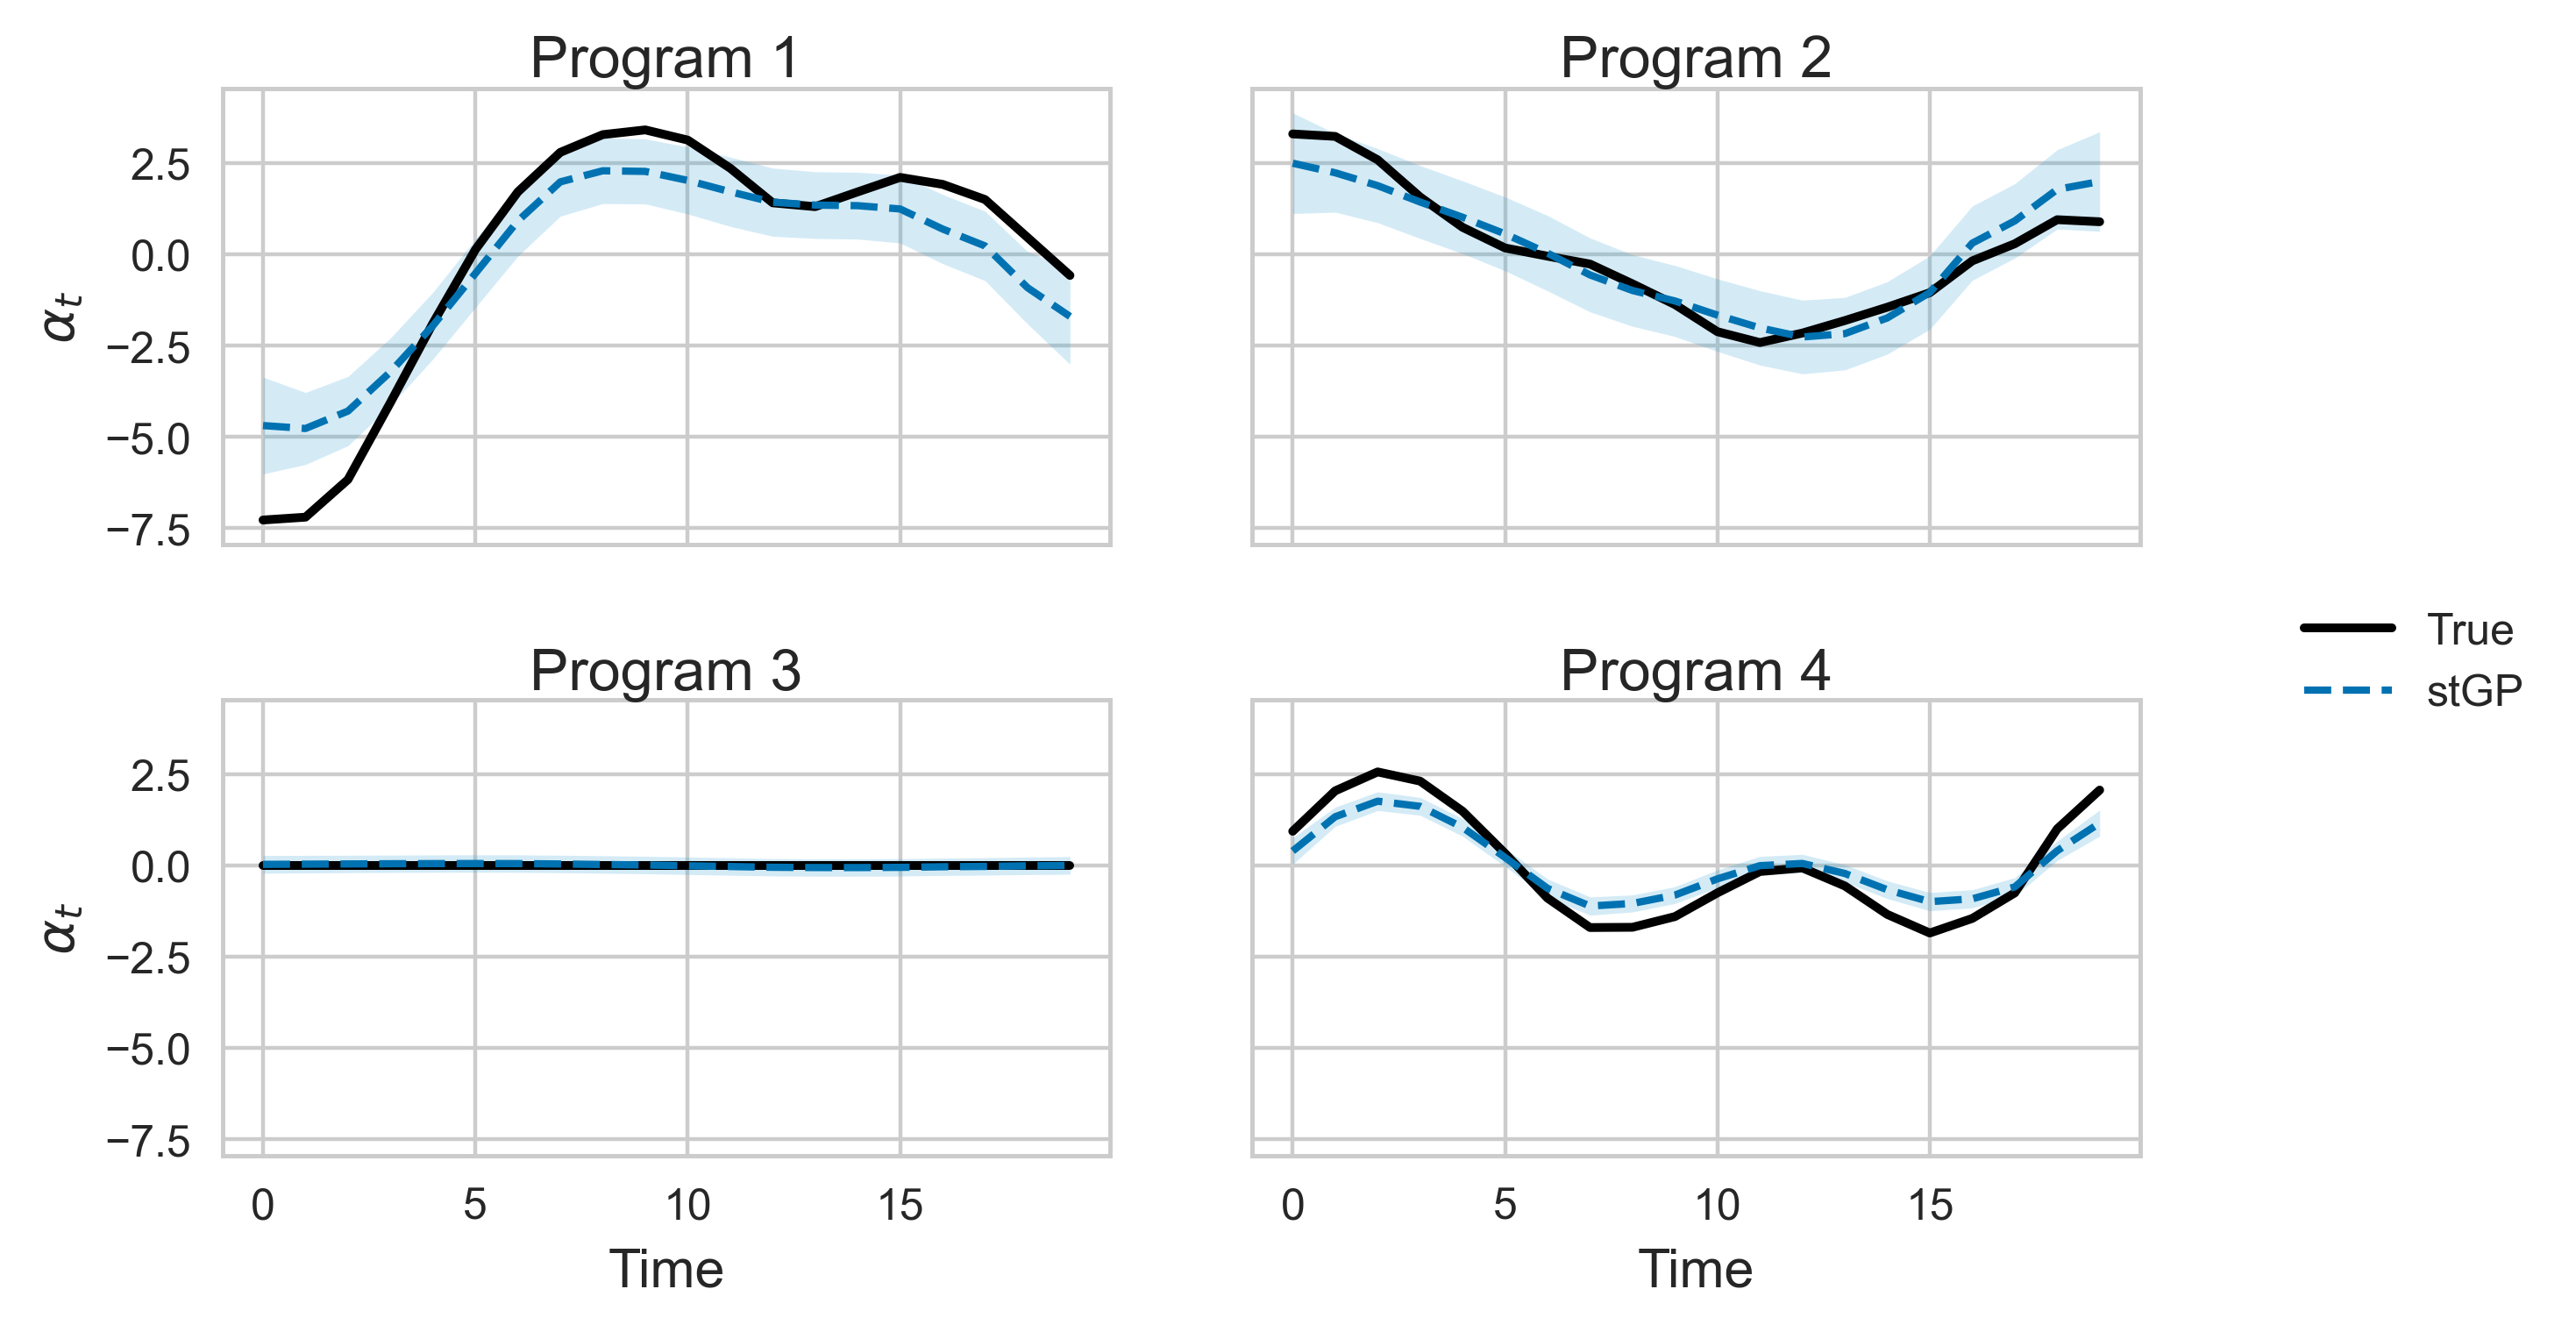

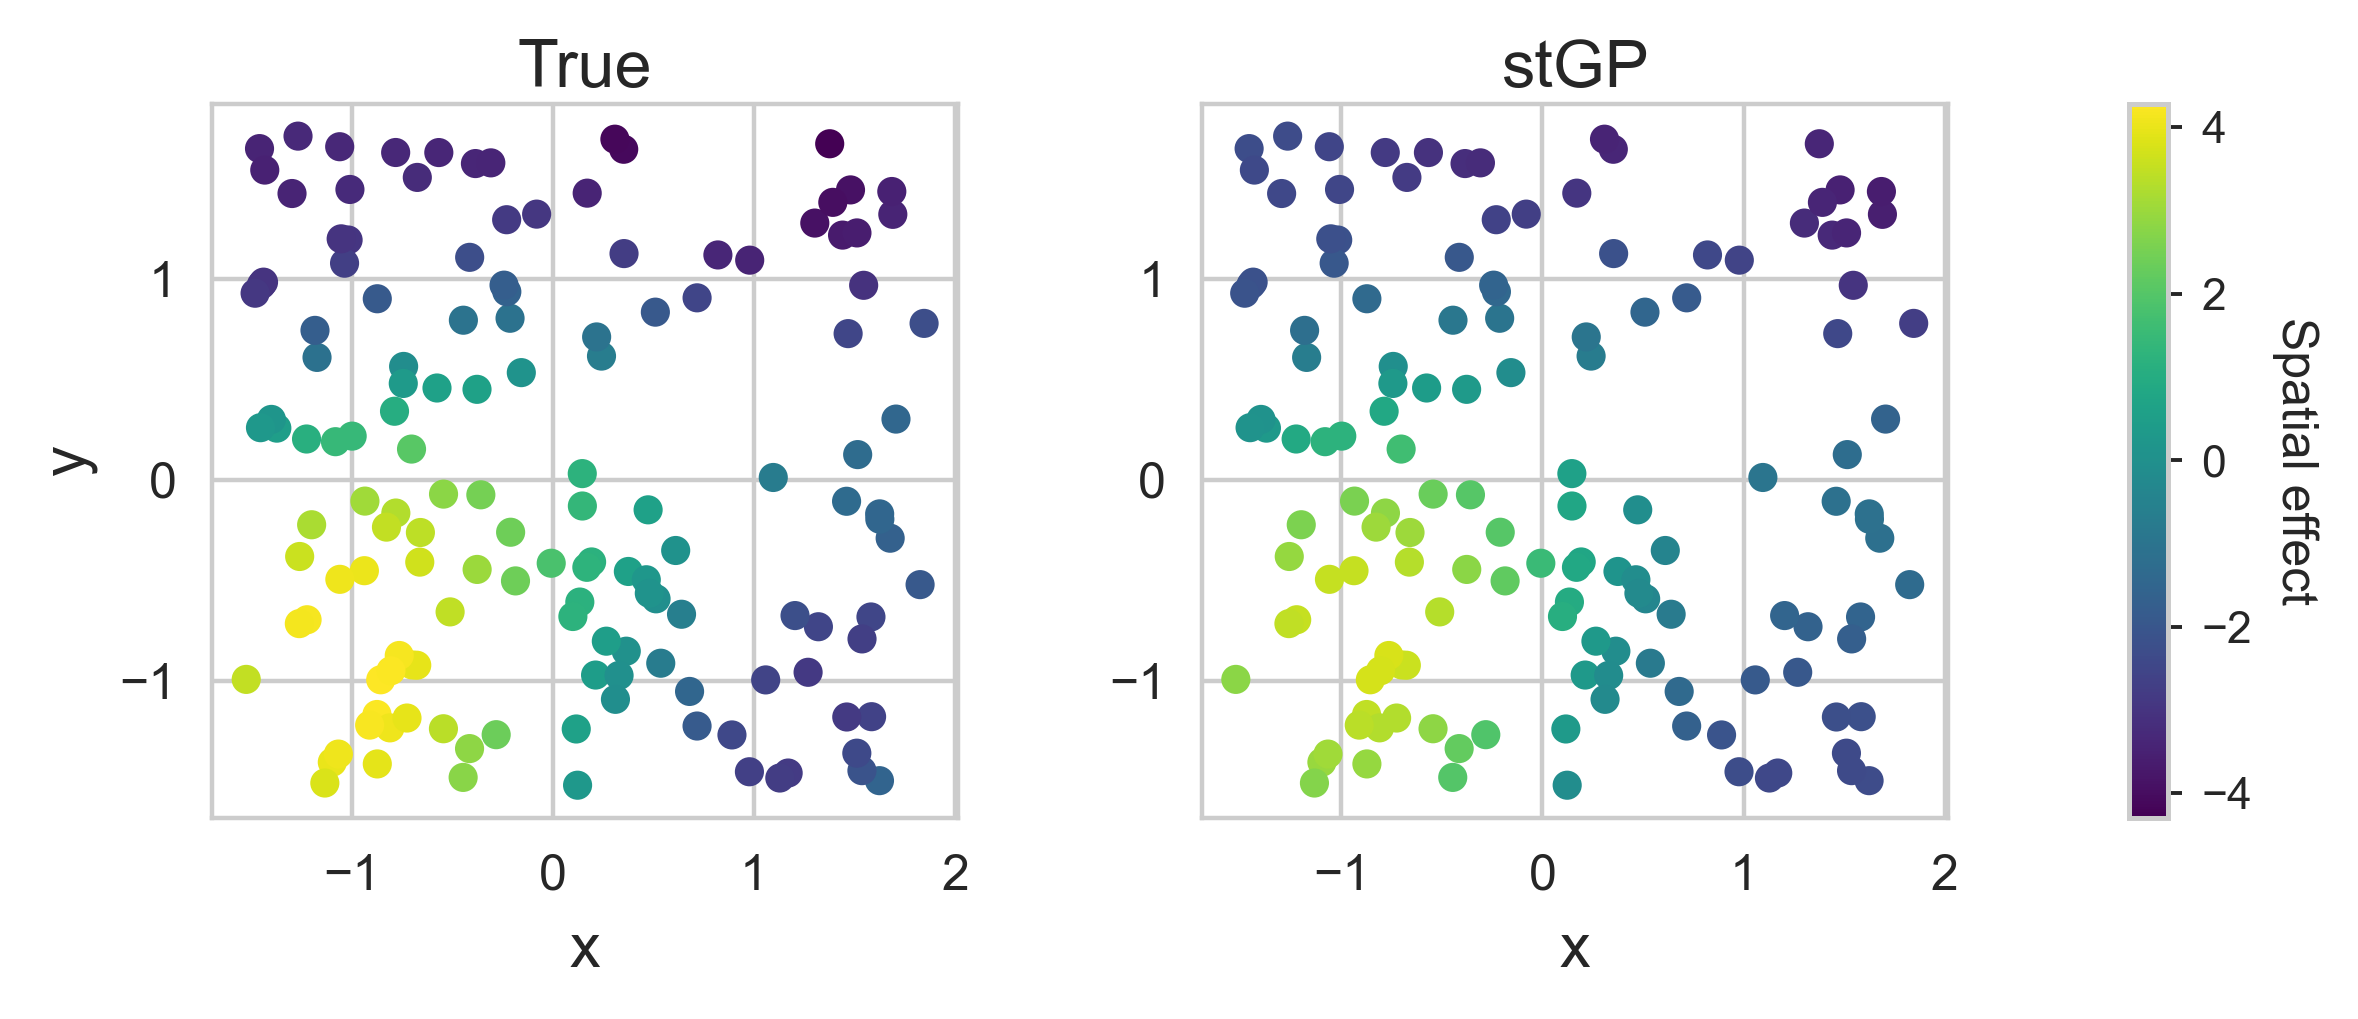

/tmp/ipykernel_355014/444961982.py:200: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  full = plt.cm.get_cmap('RdBu_r')


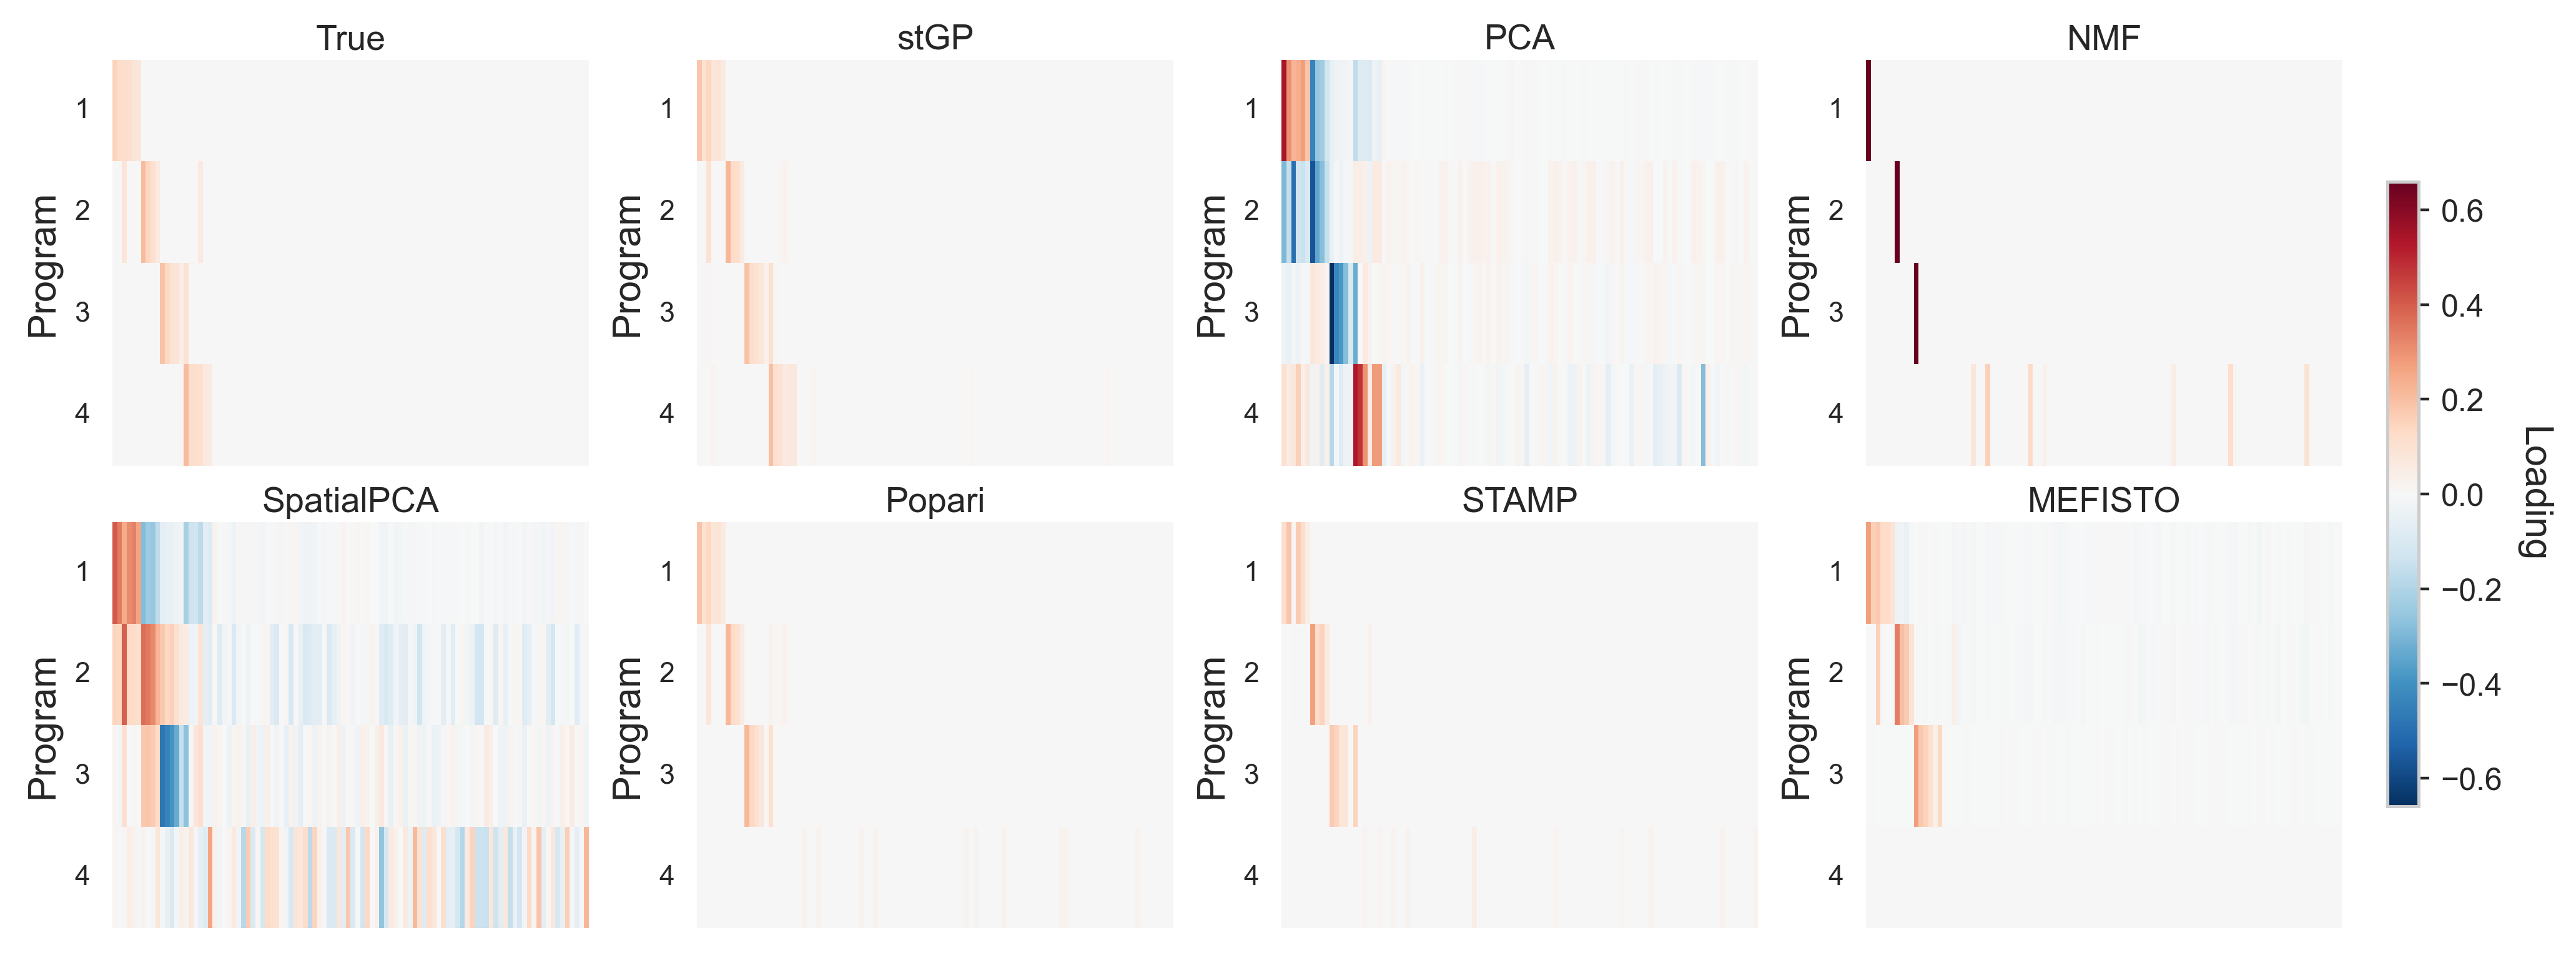

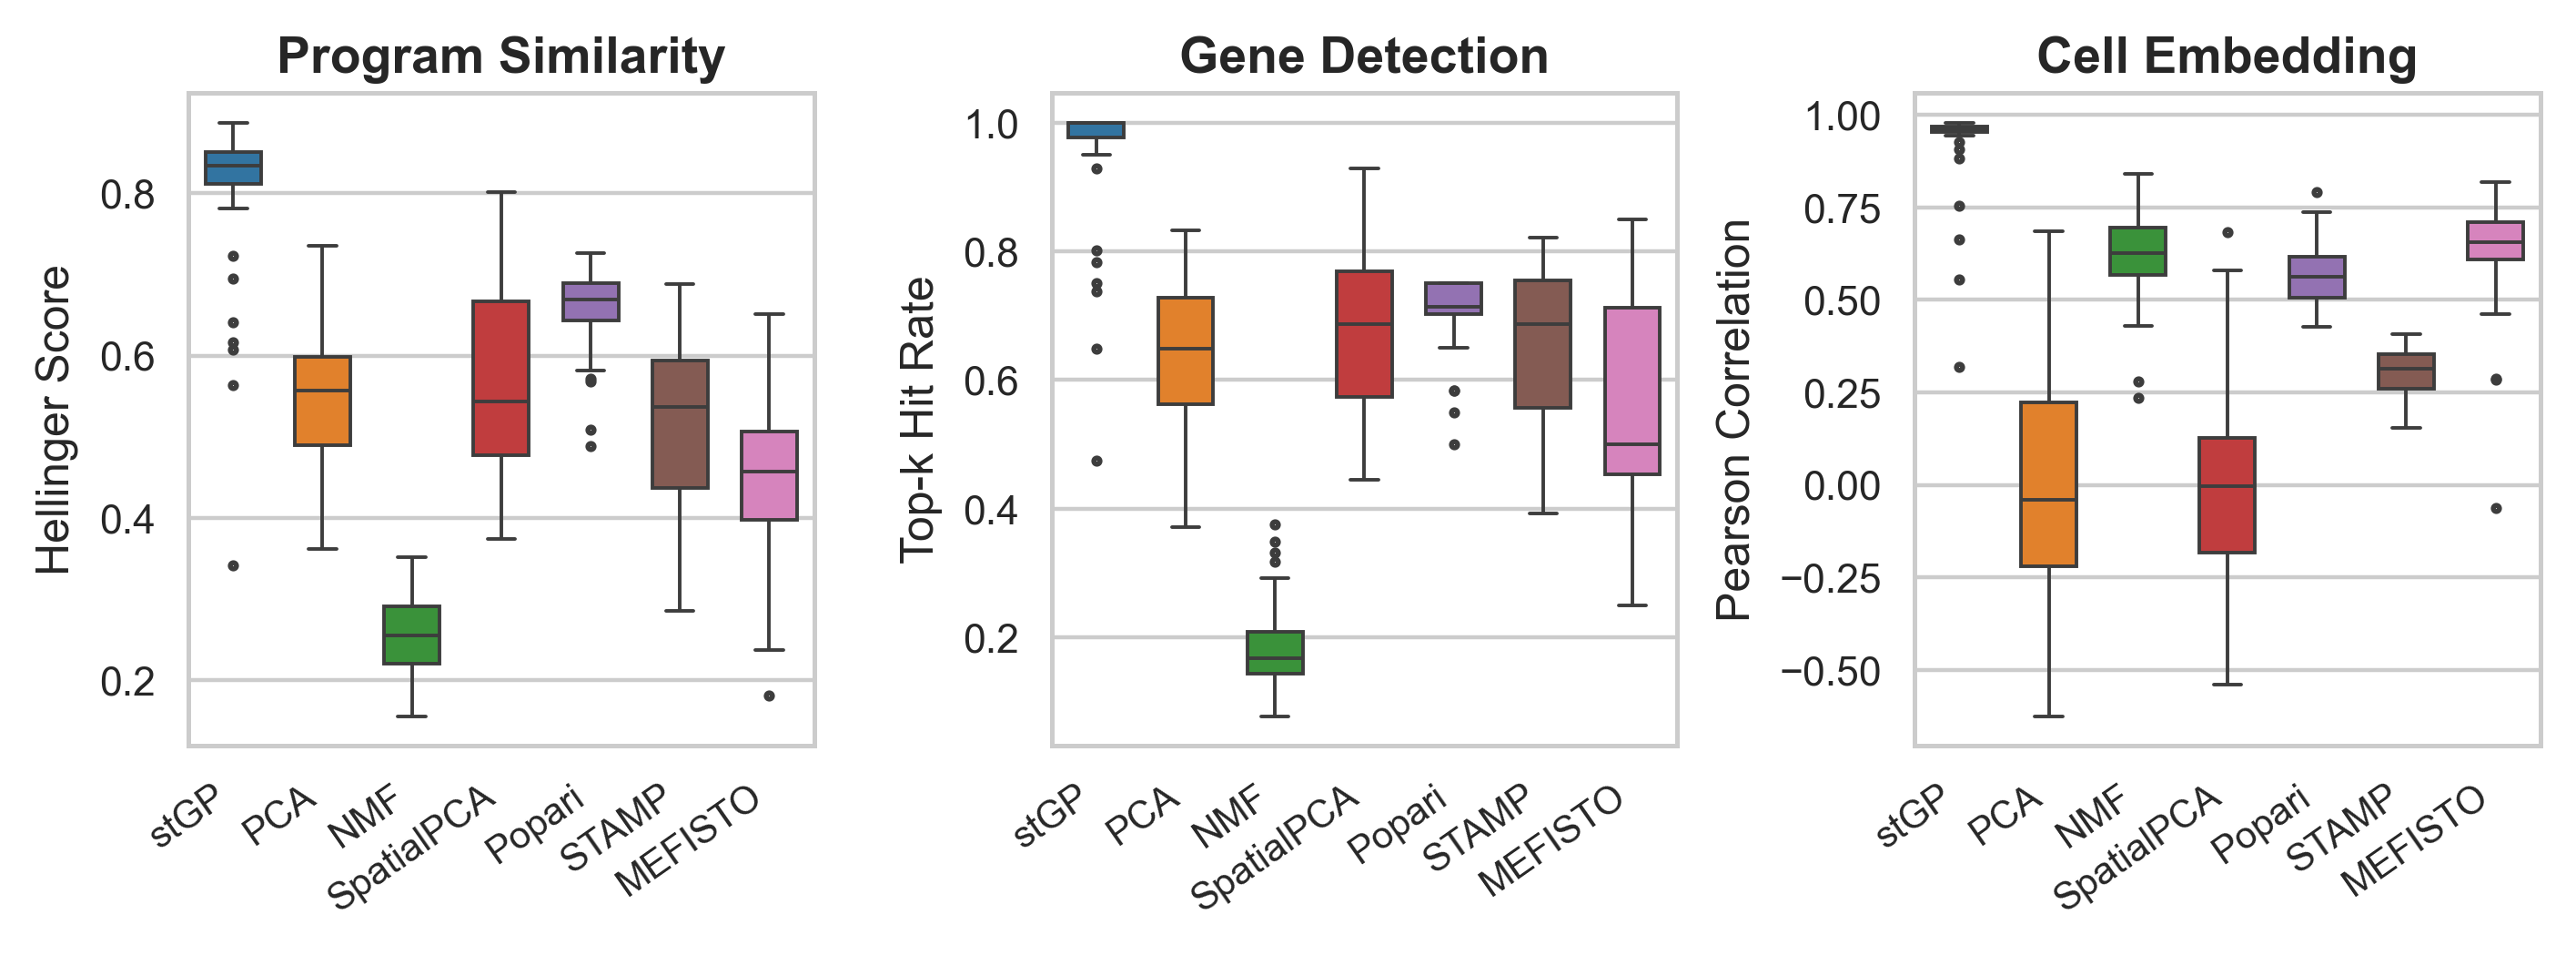

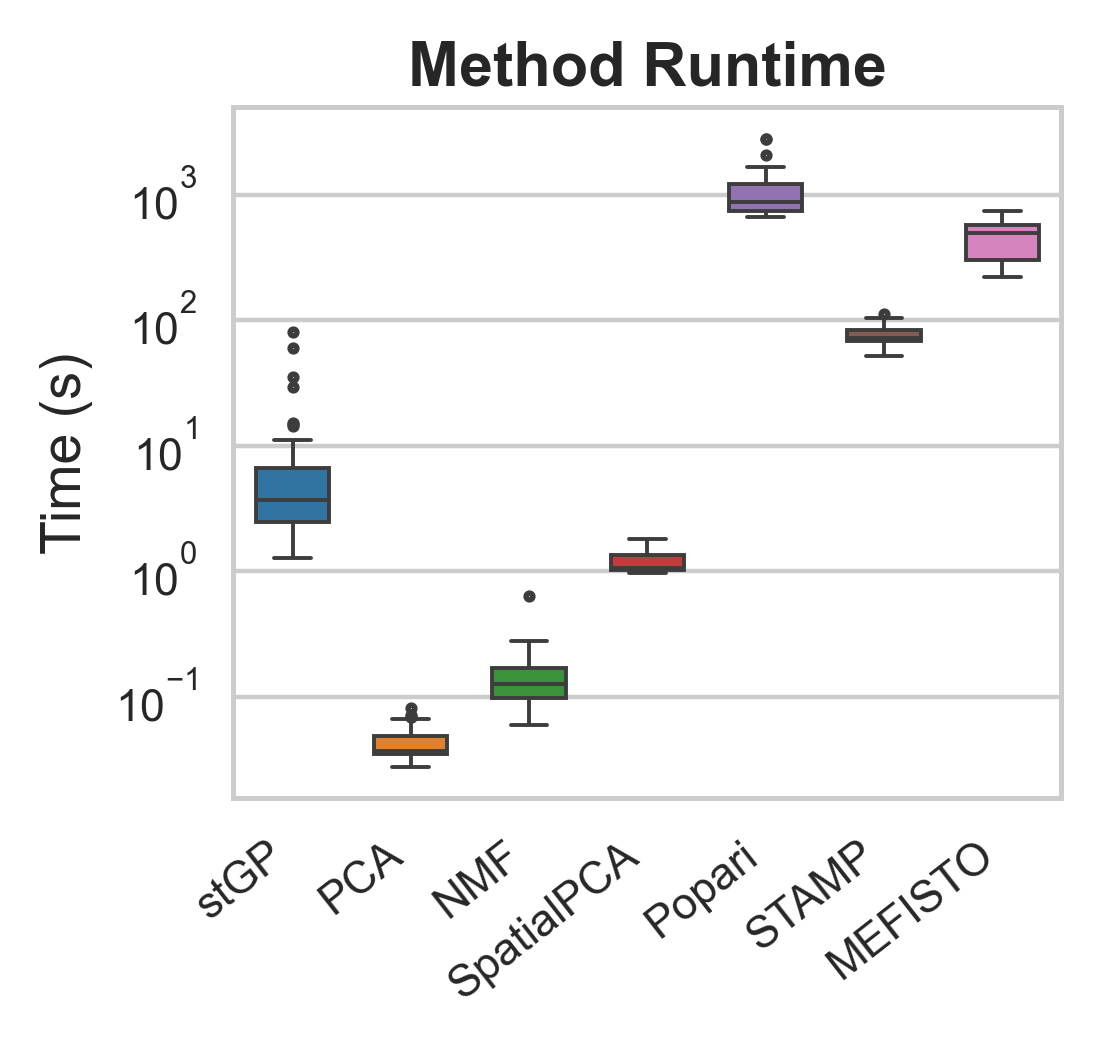

Saved /home/byual/stGP-0529/FigureReproducing/simulation/rep27_alpha_curves.png
Saved /home/byual/stGP-0529/FigureReproducing/simulation/rep27_alpha_curves.pdf
Saved /home/byual/stGP-0529/FigureReproducing/simulation/rep27_spatial_slice_prog0.png
Saved /home/byual/stGP-0529/FigureReproducing/simulation/rep27_spatial_slice_prog0.pdf
Saved /home/byual/stGP-0529/FigureReproducing/simulation/rep27_programs_heatmap_truth_ordered.png
Saved /home/byual/stGP-0529/FigureReproducing/simulation/rep27_programs_heatmap_truth_ordered.pdf
Saved /home/byual/stGP-0529/FigureReproducing/simulation/recovery_metrics_boxplot.png
Saved /home/byual/stGP-0529/FigureReproducing/simulation/recovery_metrics_boxplot.pdf
Saved /home/byual/stGP-0529/FigureReproducing/simulation/method_runtime_boxplot.png
Saved /home/byual/stGP-0529/FigureReproducing/simulation/method_runtime_boxplot.pdf


In [1]:
from pathlib import Path
import os
import pickle
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

BASE = Path(os.environ.get('STGP_REPRO_ROOT', Path.cwd().resolve()))
if not (BASE / 'FigureReproducing').exists():
    BASE = BASE.parent
FIG_REPRO_DIR = BASE / 'FigureReproducing'
SIM_DIR = BASE / 'Simulation'
RESULTS_DIR = SIM_DIR / 'results' / 'simu1'
DATASET_DIR = RESULTS_DIR / 'datasets'
FIGURE_DIR = FIG_REPRO_DIR / 'simulation'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

for pth in (BASE, SIM_DIR, FIG_REPRO_DIR):
    pth_str = str(pth)
    if pth_str not in sys.path:
        sys.path.insert(0, pth_str)

from benchmark_utils import load_method_result, true_quantities_from_datagen
from metrics_utils import align_method_for_plot, summarize_method_performance
from plot_utils import DEFAULT_RECOVERY_MAIN_METRICS
from plot import save_pair as save_figure_pair, setup_publication_style

# Purpose: count-regime Simu-1, final plotting from cached pkl files.
REP = 27
T_SLICE = 10
N_REPS = 50
PANEL_ORDER = ['stGP', 'PCA', 'NMF', 'SpatialPCA', 'SpatialPCA-nz', 'Popari', 'STAMP', 'MEFISTO']
PANEL_ORDER_MAIN = [m for m in PANEL_ORDER if m != 'SpatialPCA-nz']
METHOD_COLORS = dict(zip(PANEL_ORDER_MAIN, sns.color_palette('tab10', len(PANEL_ORDER_MAIN))))

setup_publication_style('simulation')
sns.set_style('whitegrid')


def save_pair(fig, stem, *, tight=True):
    """Save the matched high-resolution PNG and vector PDF pair for a panel."""
    return save_figure_pair(
        fig,
        stem,
        out_dir=FIGURE_DIR,
        bbox_inches='tight' if tight else None,
        pad_inches=None,
        verbose=False,
    )


def load_dataset(rep):
    with open(DATASET_DIR / f'rep_{rep}.pkl', 'rb') as f:
        payload = pickle.load(f)
    return payload['data'], payload.get('params', {})


def load_rep_results(rep, methods=PANEL_ORDER):
    out = {}
    for method in methods:
        path = RESULTS_DIR / f'{method}_rep{rep}.pkl'
        if path.exists():
            out[method], _ = load_method_result(str(path))
    return out


def alpha_bounds_for_stgp(res_stgp, perm):
    lo_raw = getattr(res_stgp, 'alpha_lower', None)
    hi_raw = getattr(res_stgp, 'alpha_upper', None)
    if lo_raw is None and res_stgp.metadata is not None:
        lo_raw = res_stgp.metadata.get('alpha_lower')
    if hi_raw is None and res_stgp.metadata is not None:
        hi_raw = res_stgp.metadata.get('alpha_upper')
    lo = np.asarray(lo_raw, dtype=float)[perm] if lo_raw is not None else None
    hi = np.asarray(hi_raw, dtype=float)[perm] if hi_raw is not None else None
    return lo, hi


def truth_gene_order(W_true):
    """Order genes by the true program with strongest loading, then within-program weight."""
    W_true = np.asarray(W_true, dtype=float)
    primary = np.argmax(W_true, axis=0)
    max_weight = W_true.max(axis=0)
    ordered = []
    bounds = []
    for j in range(W_true.shape[0]):
        idx = np.where((primary == j) & (max_weight > 1e-12))[0]
        idx = idx[np.argsort(-W_true[j, idx])]
        ordered.extend(idx.tolist())
        bounds.append(len(ordered))
    rest = np.where(max_weight <= 1e-12)[0]
    if rest.size:
        ordered.extend(rest[np.argsort(rest)].tolist())
        bounds.append(len(ordered))
    return np.asarray(ordered, dtype=int), bounds


def plot_alpha_curves_repro(data, aligned, res_stgp):
    true0 = true_quantities_from_datagen(data)
    alpha_true = true0['alpha']
    alpha_true_centered = alpha_true - alpha_true.mean(axis=1, keepdims=True)
    alpha_stgp = aligned['stGP']['alpha']
    lo, hi = alpha_bounds_for_stgp(res_stgp, aligned['stGP']['perm'])

    fig, axes = plt.subplots(2, 2, figsize=(7.1, 3.9), sharex=True, sharey=True)
    axes = axes.ravel()
    x = np.arange(alpha_true_centered.shape[1])
    y_parts = [alpha_true_centered, alpha_stgp]
    if lo is not None:
        y_parts.append(lo)
    if hi is not None:
        y_parts.append(hi)
    y_min = min(float(np.nanmin(v)) for v in y_parts)
    y_max = max(float(np.nanmax(v)) for v in y_parts)
    pad = 0.06 * (y_max - y_min) if y_max > y_min else 1.0

    for j, ax in enumerate(axes):
        ax.plot(x, alpha_true_centered[j], color='black', lw=1.8, label='True')
        if lo is not None and hi is not None:
            ax.fill_between(x, lo[j], hi[j], color='#2A9FD6', alpha=0.20, lw=0)
        ax.plot(x, alpha_stgp[j], color='#0072B2', lw=1.5, ls='--', label='stGP')
        ax.set_title(f'Program {j + 1}', fontsize=12, pad=2)
        ax.set_ylim(y_min - pad, y_max + pad)
        if j in (0, 2):
            ax.set_ylabel(r'$\alpha_t$')
        if j >= 2:
            ax.set_xlabel('Time')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.91, 0.5))
    fig.subplots_adjust(left=0.09, right=0.86, top=0.92, bottom=0.14, wspace=0.16, hspace=0.34)
    return save_pair(fig, f'rep{REP}_alpha_curves')


def plot_spatial_slice_prog0_repro(data, aligned):
    true0 = true_quantities_from_datagen(data)
    Nlist = data['Nlist']
    start = int(np.sum(Nlist[:T_SLICE]))
    end = int(np.sum(Nlist[:T_SLICE + 1]))
    coords = np.asarray(data['coords_list'][T_SLICE])
    b_true = np.asarray(true0['b'][0, start:end], dtype=float)
    b_stgp = np.asarray(aligned['stGP']['b'][start:end, 0], dtype=float)
    vmin = min(float(b_true.min()), float(b_stgp.min()))
    vmax = max(float(b_true.max()), float(b_stgp.max()))

    fig = plt.figure(figsize=(5.8, 2.55))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.045], wspace=0.20)
    axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
    cax = fig.add_subplot(gs[0, 2])
    for ax, vals, title in zip(axes, [b_true, b_stgp], ['True', 'stGP']):
        sc = ax.scatter(coords[:, 0], coords[:, 1], c=vals, cmap='viridis', s=18, vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=12, pad=3)
        ax.set_xlabel('x')
        ax.set_aspect('equal')
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.8)
    axes[0].set_ylabel('y')
    axes[1].set_ylabel('')
    cbar = fig.colorbar(sc, cax=cax)
    cbar.set_label('Spatial effect', rotation=270, labelpad=12, fontsize=9)
    cbar.ax.tick_params(labelsize=8, length=2.5, width=0.7)
    fig.subplots_adjust(left=0.08, right=0.95, bottom=0.18, top=0.88)
    return save_pair(fig, f'rep{REP}_spatial_slice_prog0')


def plot_truth_ordered_program_heatmap(W_true, aligned):
    gene_order, _ = truth_gene_order(W_true)
    signed_methods = {'PCA', 'SpatialPCA', 'MEFISTO'}
    W_true_plot = W_true / (np.sum(np.abs(W_true), axis=1, keepdims=True) + 1e-12)

    matrices = [W_true_plot[:, gene_order]]
    titles = ['True']
    signed_flags = [False]
    for method in PANEL_ORDER_MAIN:
        if method not in aligned:
            continue
        mat = aligned[method]['W_raw'] if method in signed_methods else aligned[method]['W']
        matrices.append(np.asarray(mat, dtype=float)[:, gene_order])
        titles.append(method)
        signed_flags.append(method in signed_methods)

    n_panels = len(matrices)
    nrows = min(2, n_panels)
    ncols = -(-n_panels // nrows)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(10.2, 3.7),
        constrained_layout=True,
        sharex=False,
        sharey=False,
    )
    axes = np.atleast_1d(axes).ravel()

    cmap_signed = 'RdBu_r'
    full = plt.cm.get_cmap('RdBu_r')
    cmap_nonneg = mpl.colors.LinearSegmentedColormap.from_list(
        'RdBu_r_pos', full(np.linspace(0.5, 1.0, 256))
    )
    nonneg_mats = [m for m, s in zip(matrices, signed_flags) if not s]
    signed_mats = [m for m, s in zip(matrices, signed_flags) if s]
    vmin_nn = 0.0
    vmax_nn = max((float(np.nanmax(m)) for m in nonneg_mats), default=1e-12) or 1e-12
    abs_max_s = max((float(np.nanmax(np.abs(m))) for m in signed_mats), default=1.0) or 1.0

    for ax, mat, title, is_signed in zip(axes, matrices, titles, signed_flags):
        if is_signed:
            sns.heatmap(
                mat,
                ax=ax,
                cmap=cmap_signed,
                cbar=False,
                vmin=-abs_max_s,
                vmax=abs_max_s,
                center=0,
            )
        else:
            sns.heatmap(
                mat,
                ax=ax,
                cmap=cmap_nonneg,
                cbar=False,
                vmin=vmin_nn,
                vmax=vmax_nn,
            )
        ax.set_title(title, fontsize=10, pad=3)
        ax.set_xlabel('')
        ax.set_xticks([])
        ax.set_ylabel('Program')
        ax.set_yticks(np.arange(mat.shape[0]) + 0.5)
        ax.set_yticklabels(np.arange(1, mat.shape[0] + 1), rotation=0)
        ax.tick_params(axis='y', labelsize=8)

    for ax in axes[n_panels:]:
        ax.set_visible(False)

    sm = plt.cm.ScalarMappable(
        cmap=cmap_signed,
        norm=plt.Normalize(vmin=-abs_max_s, vmax=abs_max_s),
    )
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=list(axes[:n_panels]), shrink=0.72, location='right', pad=0.02)
    cbar.set_label('Loading', rotation=270, labelpad=14)
    return save_pair(fig, f'rep{REP}_programs_heatmap_truth_ordered')


RECOVERY_TITLES = {
    'hellinger_score': 'Program Similarity',
    'gene_topk_hit_mean': 'Gene Detection',
    'H_corr': 'Cell Embedding',
}
RECOVERY_YLABELS = {
    'hellinger_score': 'Hellinger Score',
    'gene_topk_hit_mean': 'Top-k Hit Rate',
    'H_corr': 'Pearson Correlation',
}


def plot_recovery_boxplot(df):
    metric_cols = [c for c in DEFAULT_RECOVERY_MAIN_METRICS if c in df.columns]
    method_order = [m for m in PANEL_ORDER_MAIN if m in set(df['method'])]
    fig, axes = plt.subplots(1, len(metric_cols), figsize=(7.1, 3.2), sharex=False)
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, metric_cols):
        sub = df[['method', col]].dropna()
        sns.boxplot(
            data=sub,
            x='method',
            y=col,
            order=method_order,
            hue='method',
            hue_order=method_order,
            palette=METHOD_COLORS,
            legend=False,
            ax=ax,
            fliersize=1.2,
            linewidth=0.7,
            width=0.62,
        )
        ax.set_xlabel('')
        ax.set_ylabel(RECOVERY_YLABELS.get(col, col), fontsize=9)
        ax.set_title(RECOVERY_TITLES.get(col, col), fontsize=10, fontweight='bold', pad=4)
        ax.set_xticks(ax.get_xticks())
        ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=7.5)
        ax.tick_params(axis='y', labelsize=8)
    fig.subplots_adjust(left=0.08, right=0.99, top=0.86, bottom=0.30, wspace=0.38)
    return save_pair(fig, 'recovery_metrics_boxplot')


def plot_runtime_boxplot(df_rt):
    method_order = [m for m in PANEL_ORDER_MAIN if m in set(df_rt['method'])]
    sub = df_rt[['method', 'runtime']].dropna()
    fig, ax = plt.subplots(1, 1, figsize=(3.0, 3.2))
    sns.boxplot(
        data=sub,
        x='method',
        y='runtime',
        order=method_order,
        hue='method',
        hue_order=method_order,
        palette=METHOD_COLORS,
        legend=False,
        ax=ax,
        fliersize=1.2,
        linewidth=0.7,
        width=0.62,
    )
    ax.set_xlabel('')
    ax.set_ylabel('Time (s)', fontsize=10)
    ax.set_title('Method Runtime', fontsize=11, fontweight='bold', pad=4)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=38, ha='right', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    if float(sub['runtime'].min()) > 0.0:
        ax.set_yscale('log')
    fig.subplots_adjust(left=0.28, right=0.97, top=0.86, bottom=0.32)
    return save_pair(fig, 'method_runtime_boxplot')


# Replicate-specific panels: same cached data/results as simu_gaussian.py --stage plot.
data_rep, params_rep = load_dataset(REP)
rep_results = load_rep_results(REP)
true_rep = true_quantities_from_datagen(data_rep)
W_true = np.asarray(true_rep['W'], dtype=float)
aligned = {}
for name, res in rep_results.items():
    W_al, alpha_al, b_al, perm, W_raw = align_method_for_plot(W_true, res, Nlist=data_rep['Nlist'])
    aligned[name] = {'W': W_al, 'alpha': alpha_al, 'b': b_al, 'perm': perm, 'W_raw': W_raw}

if 'stGP' not in rep_results:
    raise RuntimeError(f'stGP result is required for rep={REP} panels.')

saved_files = []
saved_files.extend(plot_alpha_curves_repro(data_rep, aligned, rep_results['stGP']))
saved_files.extend(plot_spatial_slice_prog0_repro(data_rep, aligned))
saved_files.extend(plot_truth_ordered_program_heatmap(W_true, aligned))

# Multi-replicate metrics/runtime panels: recompute plot-stage summaries from cached pkl files.
metric_rows = []
runtime_rows = []
for rep in range(N_REPS):
    data_i, params_i = load_dataset(rep)
    true_i = dict(true_quantities_from_datagen(data_i))
    true_i['H_list'] = data_i['H_list']
    k_i = int(params_i.get('k', 10))
    for method, res in load_rep_results(rep).items():
        meta = res.metadata or {}
        if meta.get('runtime') is not None:
            runtime_rows.append({'method': method, 'rep': rep, 'runtime': float(meta['runtime'])})
        metrics = summarize_method_performance(
            true_i,
            res,
            tau=0.9,
            align_sparsify_topk=k_i,
            align_sparsify_frac=None,
        )
        metrics['method'] = method
        metrics['rep'] = rep
        metric_rows.append(metrics)

df_metrics = pd.DataFrame(metric_rows)
df_runtime = pd.DataFrame(runtime_rows)
df_metrics.to_csv(FIGURE_DIR / 'recovery_metrics_multirep.csv', index=False)
df_runtime.to_csv(FIGURE_DIR / 'method_runtime_multirep.csv', index=False)
saved_files.extend(plot_recovery_boxplot(df_metrics))
saved_files.extend(plot_runtime_boxplot(df_runtime))

for path in saved_files:
    print(f'Saved {path}')